In [1]:
import pandas as pd
import sys 
sys.path.append('../')
import matplotlib.pyplot as plt

In [10]:
partitions = pd.read_parquet('../data/alerce_data/partitions/241015/partitions.parquet')

In [11]:
#order partitions by oid
partitions = partitions.sort_values(by='oid')

In [12]:
classes = partitions['alerceclass'].unique()
print(classes)

['RRLc' 'LPV' 'RRLab' 'EA' 'RSCVn' 'YSO' 'EB/EW' 'CV/Nova' 'DSCT' 'CEP'
 'Blazar' 'AGN' 'Periodic-Other' 'SNIIb' 'QSO' 'TDE' 'SNIa' 'SNII' 'SNIbc'
 'SLSN' 'SNIIn' 'Microlensing']


In [13]:
periodic_classes = ['RRLc' ,'LPV' ,'RRLab', 'EA','EB/EW','DSCT','Ceph','Periodic-Other']

In [14]:
partitions_p = partitions[partitions['alerceclass'].isin(periodic_classes)]


In [15]:
#count unique oids
unique_oids = partitions_p['oid'].unique()

In [16]:
unique_oids.shape

(17923,)

In [17]:
processed_data= pd.read_parquet('../data/alerce_data/data_241015')

In [18]:
processed_data.columns

Index(['oid', 'index', 'mjd', 'fid', 'mag_tot', 'sigma_mag_tot',
       'flux_diff_ujy', 'sigma_flux_diff_ujy', 'detected', 'dnearestrefsrc',
       'rfid', 'nearestrefsharp', 'nearestrefchi'],
      dtype='object')

In [19]:
oids = processed_data['oid'].unique()

In [20]:
oid = oids[1]

In [21]:
import time

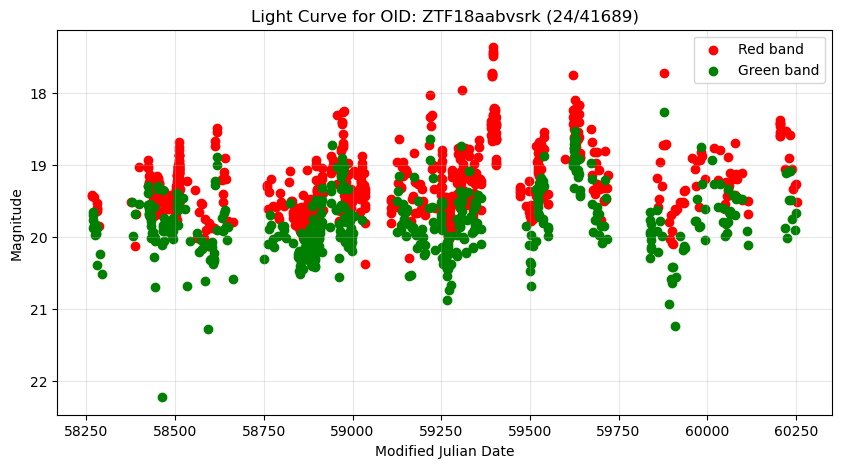

Button(button_style='info', description='Next OID', layout=Layout(height='40px', width='200px'), style=ButtonS…

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# Create button with styling
button = widgets.Button(
    description='Next OID',
    button_style='info', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Click to show next OID',
    layout=widgets.Layout(width='200px', height='40px')
)

# Initialize current index
current_idx = [0]

def on_button_clicked(b):
    clear_output(wait=True)
    # Update index
    current_idx[0] = (current_idx[0] + 1) % len(oids)
    # Plot new data
    oid = oids[current_idx[0]]
    oid_data = processed_data[processed_data['oid']==oid]
    red_data = oid_data[oid_data['fid']==2]
    green_data = oid_data[oid_data['fid']==1]
    
    plt.figure(figsize=(10,5))
    plt.scatter(red_data['mjd'], red_data['mag_tot'], color='red', label='Red band')
    plt.scatter(green_data['mjd'], green_data['mag_tot'], color='green', label='Green band')
    plt.title(f'Light Curve for OID: {oid} ({current_idx[0]+1}/{len(oids)})')
    plt.xlabel('Modified Julian Date') 
    plt.ylabel('Magnitude')
    plt.gca().invert_yaxis()
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    display(button)

# Assign callback to button
button.on_click(on_button_clicked)

# Display initial button and plot
display(button)
on_button_clicked(None)  # Show first plot

In [4]:
import pandas as pd

In [16]:
# for all files in the directory read all the data using pandas with csv and concatenate all the data
import os
import glob

path = '/home/fsoto/Documents/LCsSSL/data/rldl'
all_files = glob.glob(os.path.join(path, "*.csv"))

#only keep the
df_from_each_file = (pd.read_csv(f) for f in all_files)
df = pd.concat(df_from_each_file, ignore_index=True)



In [17]:
#df = pd.read_csv('/home/fsoto/Documents/LCsSSL/data/rldl/Periodic-Other_lcname_firstmjd.csv')

In [18]:
df

,oid,ra,dec,name_lc,firstmjd_al
0,ZTF17aaawhcz,309.148749,34.782518,lc_309.14874902278666_34.782518290130625_24581...,58257.433796
1,ZTF17aackrmj,144.856653,34.248023,lc_144.85665336346153_34.2480229_2458194.5_247...,58424.537859
2,ZTF17aacpdba,78.657978,20.622566,lc_78.65797757011495_20.622566198850578_245819...,58457.247986
3,ZTF18aaadvnw,55.939848,39.873544,lc_55.939847659259264_39.87354421384016_245819...,58370.442905
4,ZTF18aabezap,53.423275,48.994846,lc_53.42327516525423_48.994846054237286_245819...,58343.450393
...,...,...,...,...,...
9759,ZTF20aabqlkg,171.396789,-4.315919,lc_171.396789084_-4.315919144_2458194.5_247000...,58828.542824
9760,ZTF20aacdnck,254.318978,3.199070,lc_254.31897776101687_3.1990695830508478_24581...,58886.482025
9761,ZTF20aakswiy,296.788157,23.100023,lc_296.788157_23.1000235_2458194.5_2470000.5.txt,59248.552049
9762,ZTF21aaeqjod,71.442050,-17.812431,lc_71.44205038666668_-17.81243076666666_245819...,59243.206424


In [19]:
detections_adquired = pd.read_parquet('/home/fsoto/Documents/LCsSSL/data/adquire/detections_adquired.parquet')

In [20]:
oids = detections_adquired['oid'].unique()

In [21]:
#find the oid in the detections_adquired that are in the df
df = df[df['oid'].isin(oids)]

In [22]:
df

,oid,ra,dec,name_lc,firstmjd_al
1,ZTF17aackrmj,144.856653,34.248023,lc_144.85665336346153_34.2480229_2458194.5_247...,58424.537859
92,ZTF19abqoxuo,266.953261,-23.341157,lc_266.9532608851852_-23.341157033333328_24581...,58715.240417
133,ZTF18abiygrq,274.622506,-9.319268,lc_274.6225062019231_-9.319267763461538_245819...,58321.274572
190,ZTF19aaxtygc,277.430888,-23.594157,lc_277.4308882153846_-23.594156543589747_24581...,58640.354896
209,ZTF17aaawhhq,303.423566,37.712908,lc_303.4235663215569_37.712908361676654_245819...,58280.429144
...,...,...,...,...,...
9726,ZTF18abupzae,105.442016,43.327870,lc_105.44201558526316_43.32786965473684_245819...,58371.513854
9734,ZTF18acjngrt,301.900359,33.902815,lc_301.90035930275866_33.9028153_2458194.5_247...,58425.131701
9746,ZTF19aamokbz,217.668860,-9.085773,lc_217.6688598_-9.085772924242423_2458194.5_24...,58540.460671
9756,ZTF19acbhpmw,103.260744,-14.414811,lc_103.26074388913048_-14.414810754347824_2458...,58751.480220


In [15]:
#read h5 file
import h5py
import numpy as np


f = h5py.File('/home/fsoto/Documents/LCsSSL/data/fpv1/forced_photometry_v1.h5', 'r')

In [5]:
f['mag_tot'].shape

(9764, 1000, 2)